# Fase 0: Lettura dei dati e EDA (Exploratory Data Analysis)

In [14]:
import pandas as pd
dataset = "gemma_v3.csv"
df = pd.read_csv(dataset)
df.sample(10)

,id,title,body,category,priority
98,TK-98,Urgente: non va configurazione server,Vi scrivo perché ho un po' di anomalie nella c...,Tecnico,Media
124,TK-124,Info per configurazione VPN lenta,"Ho già provato a riavviare, ma la connessione ...",Tecnico,Media
306,TK-306,Procedura per blocco fatturazione urgente,"Buongiorno, ho un problema con la procedura di...",Amministrazione,Alta
68,TK-68,Chiarimento su configurazione iniziale del sis...,"Gentile supporto, vi contatto per una domanda ...",Commerciale,Bassa
148,TK-148,Problemi con l'integrazione API,Vi scrivo perché ho notato un rallentamento ne...,Tecnico,Media
22,TK-22,Procedura per gestione note spese,"Scusate il disturbo, ho un problema con la pro...",Amministrazione,Media
406,TK-406,Non va la sincronizzazione dei dati,"Ho già provato a riavviare, ma il sistema cont...",Commerciale,Media
274,TK-274,Errore Configurazione software,Potete dare un occhiata a come posso resettare...,Tecnico,Bassa
446,TK-446,Aiuto: Blocco totale sistema contabilità,"Ciao, ho un blocco totale nel sistema di gesti...",Amministrazione,Alta
11,TK-11,Errore gestione spese,"Non volevo proprio dirlo, ma ho un problema co...",Amministrazione,Bassa


In [15]:
df['category'].value_counts(ascending=False)

category
Amministrazione    178
Tecnico            165
Commerciale        157
Name: count, dtype: int64

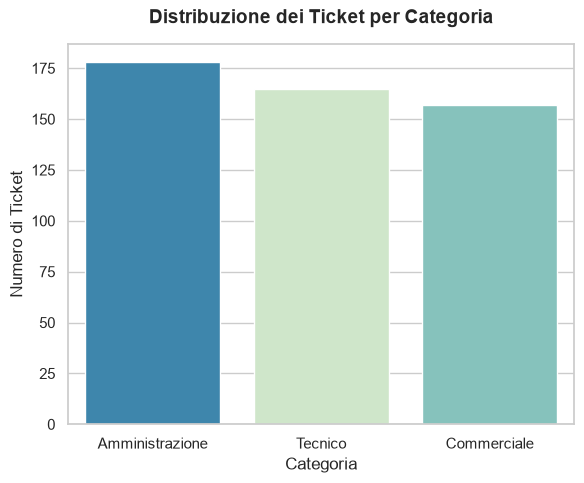

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# GRAFICO 1: Numero di ticket per ogni categoria (in ordine decrescente)

#ordine delle categorie dal valore più alto al più basso
ordine_categorie = df['category'].value_counts().index

fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.countplot(
    data=df, 
    x='category', 
    order=ordine_categorie, 
    hue='category', 
    palette='GnBu_r', 
    ax=ax1
)

#rimuovo la legenda automatica del parametro 'hue' che in questo caso è ridondante
if ax1.get_legend() is not None:
    ax1.get_legend().remove()

ax1.set_title('Distribuzione dei Ticket per Categoria', fontsize=14, pad=15, fontweight='bold')
ax1.set_xlabel('Categoria', fontsize=12)
ax1.set_ylabel('Numero di Ticket', fontsize=12)

plt.tight_layout()
plt.show()


In [17]:
df.groupby('category')['priority'].value_counts(ascending=False)

category         priority
Amministrazione  Bassa       62
                 Alta        60
                 Media       56
Commerciale      Alta        61
                 Media       49
                 Bassa       47
Tecnico          Media       59
                 Alta        56
                 Bassa       50
Name: count, dtype: int64

In [18]:
df['priority'].value_counts(ascending=False)

priority
Alta     177
Media    164
Bassa    159
Name: count, dtype: int64

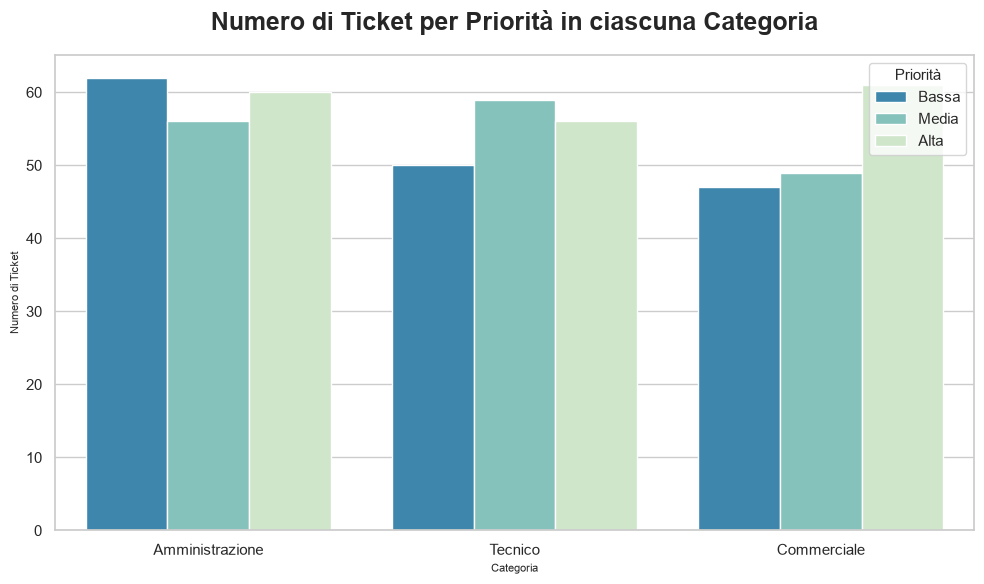

In [19]:
fig2, ax2 = plt.subplots(figsize=(10, 6))

order = ['Amministrazione', 'Tecnico', 'Commerciale']
sns.countplot(
    data=df, 
    x='category',
    order = order, 
    hue='priority', 
    hue_order=['Bassa', 'Media', 'Alta'],
    palette='GnBu_r', 
    ax=ax2
)

#leggenda ed etichette varie
ax2.set_title('Numero di Ticket per Priorità in ciascuna Categoria', fontsize=18, pad=18, fontweight='bold')
ax2.set_xlabel('Categoria', fontsize=8)
ax2.set_ylabel('Numero di Ticket', fontsize=8)
ax2.legend(title='Priorità', title_fontsize='11', loc='upper right')


plt.tight_layout()
plt.show()

word count

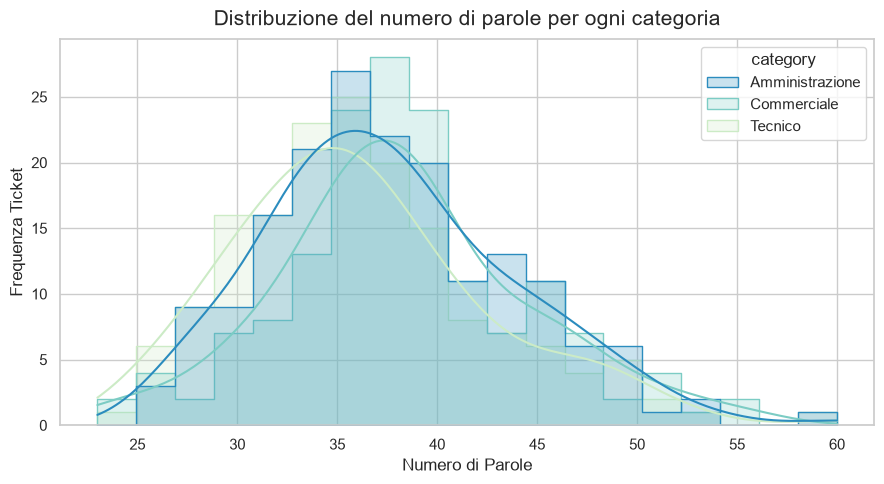

In [20]:
df['ticket_completo'] = df['title'].fillna('') + " " + df['body'].fillna('')
df['word_count'] = df['ticket_completo'].apply(lambda x: len(x.split()))

#grafico della distribuzione della lunghezza
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x='word_count', hue='category', kde=True, element='step', palette='GnBu_r', ax=ax)

ax.set_title('Distribuzione del numero di parole per ogni categoria', fontsize=15, pad=10)
ax.set_xlabel('Numero di Parole')
ax.set_ylabel('Frequenza Ticket')

plt.tight_layout()
plt.show()

# Preprocessing del testo, ovvero pulizia base del testo (minuscole, rimozione punteggiatura), tokenizzazione.

cancella i nan

In [21]:
df = df.dropna(subset=['title','category', 'priority','body'])

pulisce il testo usando solo regex. rimuove tutto ciò che non è una lettera o un numero e rimuove gli spazi in generale

In [22]:
import re
import pandas as pd

def clean_text(text):
    
    text = str(text).lower()
    
    #^\w\s significa "tutto ciò che NON è una lettera/numero (\w) o uno spazio (\s)"
    text = re.sub(r'[^\w\s]', '', text)
    
    #rimuove spazi in generale
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


esempio di pulizia in un record estratto a caso (prima e dopo)

In [23]:
test_record = df.sample(n=1)

print("--- RECORD REALE ESTRATTO ---")
print(test_record[['title','category', 'priority','body']])

print("\n--- RISULTATO DOPO LA PULIZIA ---")
clean_record = test_record[['title', 'category', 'priority','body']].map(clean_text)
print(clean_record)

--- RECORD REALE ESTRATTO ---
                                                title     category priority  \
71  Richiesta chiarimenti blocco fatturazione imme...  Commerciale     Alta   

                                                 body  
71  Così non posso lavorare! Il sistema di invoici...  

--- RISULTATO DOPO LA PULIZIA ---
                                                title     category priority  \
71  richiesta chiarimenti blocco fatturazione imme...  commerciale     alta   

                                                 body  
71  così non posso lavorare il sistema di invoicin...  


per questa fase, ho preso spunto dal corso di programmazione 2, in particolare nella sezione di programmazione strutturata.

si crea una nuova colonna dove si mettono tutti i token

In [24]:
df[['title', 'category', 'priority','body']]= df[['title', 'category', 'priority','body']].map(clean_text)

df['token'] = df['ticket_completo'].str.split()
df.sample(10)['token']
len(df['token'])

500

altro EDA per vedere le parole più frequenti

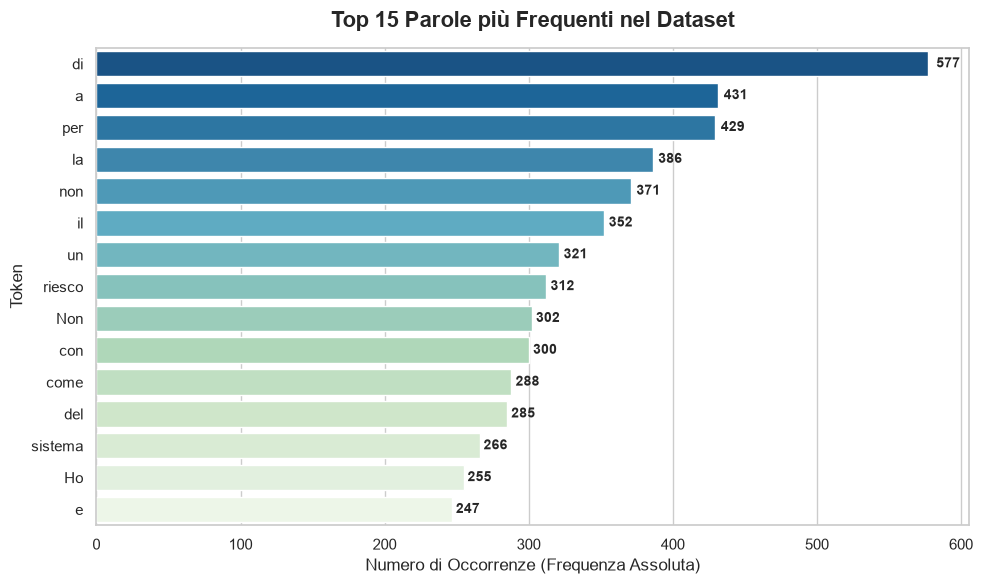

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

top_words = df['token'].explode().value_counts().head(15).reset_index()

top_words.columns = ['Parola', 'Frequenza']

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid") #sfondo pulito con griglia leggera

#grafico a barre orizzontali (barpot)
sns.barplot(
    x='Frequenza', 
    y='Parola', 
    data=top_words, 
    palette='GnBu_r', 
    hue='Parola',
    legend=False
)

#personalizza i testi e i titoli
plt.title('Top 15 Parole più Frequenti nel Dataset', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Numero di Occorrenze (Frequenza Assoluta)', fontsize=12)
plt.ylabel('Token', fontsize=12)

#per mettere in risalto i valori numerici alla fine di ogni barra
for index, value in enumerate(top_words['Frequenza']):
    plt.text(value + (value * 0.01), index, f'{int(value)}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

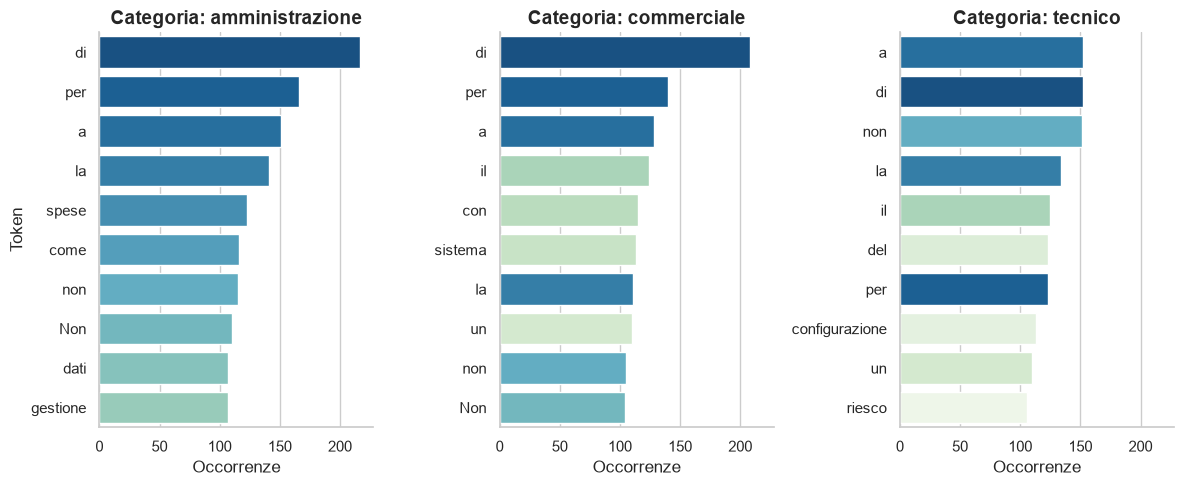

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
words_by_category = (df[['category', 'token']]
                     .explode('token')
                     .groupby(['category', 'token'])
                     .size()
                     .reset_index(name='Frequenza'))

#solo le top 10 parole per ogni singola categoria per non affollare il grafico
top_words_per_cat = (words_by_category
                     .sort_values(['category', 'Frequenza'], ascending=[True, False])
                     .groupby('category')
                     .head(10))

top_words_per_cat = top_words_per_cat.rename(columns={'token': 'Parola'})

g = sns.catplot(
    data=top_words_per_cat, 
    kind="bar",
    x="Frequenza",  
    y="Parola",
    col="category",
    palette="GnBu_r",
    hue="Parola",
    legend=False,
    sharey=False,
    height=5, 
    aspect=0.8
)

g.set_titles("Categoria: {col_name}", size=14, weight='bold')
g.set_xlabels("Occorrenze", size=12)
g.set_ylabels("Token", size=12)


plt.show()

scrivere che già con la tokenizzation non è male, ma si potrebbe fare altra roba come lemming e simili, ma che per il momento procederò così per vedere i risultati iniziali e fare poi un confronto e rimuovendo le stop word

# Fase 2, sono in blind run da qui in poi, DA RICONTROLLARE QUANDO SI FARANNO LE LEZIONI DI PROGRAMMAZIONE 2

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Caricamento dati e preparazione testo
dataset = "gemma_v3.csv"
df = pd.read_csv(dataset, lineterminator='\n')

# Uniamo titolo e descrizione per dare massimo contesto al modello
df['testo_completo'] = df['title'].fillna('') + " " + df['body'].fillna('')

# Definiamo le Feature (X) e il Target (y)
X = df['testo_completo']
y = df['category']

# 2. Suddivisione in Train Set (80%) e Test Set (20%)
# Usiamo stratify=y per garantire la stessa proporzione di categorie in train e test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

# 3. Estrazione delle Feature con TF-IDF
# sublinear_tf=True migliora la gestione dei testi di lunghezza variabile
# ngram_range=(1, 2) cattura sia parole singole che coppie di parole (es. "nota spese")
vectorizer = TfidfVectorizer(
    sublinear_tf=True, 
    min_df=5, 
    ngram_range=(1, 2), 
    stop_words=None # Imposta a 'english' o usa una lista se vuoi filtrare, ma LinearSVC è robusto anche senza
)

# Calcoliamo il TF-IDF sui dati di Train e lo applichiamo al Test
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 4. Addestramento del Modello (LinearSVC)
modello_categoria = LinearSVC(random_state=42, dual=False)
modello_categoria.fit(X_train_tfidf, y_train)

# 5. Predizione e Valutazione Base
y_pred = modello_categoria.predict(X_test_tfidf)

print("--- VALUTAZIONE MODELLO CATEGORIA ---")
print(f"Accuracy Totale: {accuracy_score(y_test, y_pred):.4f}\n")
print("Report di Classificazione (comprende F1-Macro):")
print(classification_report(y_test, y_pred))

--- VALUTAZIONE MODELLO CATEGORIA ---
Accuracy Totale: 0.9067

Report di Classificazione (comprende F1-Macro):
                 precision    recall  f1-score   support

Amministrazione       0.96      0.89      0.92        53
    Commerciale       0.87      0.87      0.87        47
        Tecnico       0.89      0.96      0.92        50

       accuracy                           0.91       150
      macro avg       0.91      0.91      0.91       150
   weighted avg       0.91      0.91      0.91       150



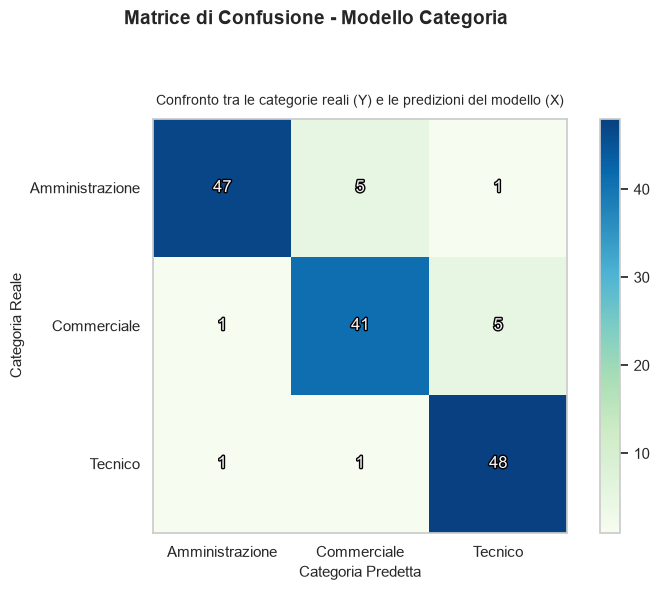

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.patheffects as path_effects

# 1. Calcoliamo la matrice di confusione numerica
cm = confusion_matrix(y_test, y_pred, labels=modello_categoria.classes_)

# 2. Creiamo la visualizzazione grafica nativa di Scikit-Learn
fig, ax = plt.subplots(figsize=(8, 6),)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modello_categoria.classes_)

# Disegniamo la matrice impostando una mappa di colori (es. 'Blues')
disp.plot(cmap='GnBu', ax=ax, values_format='d') # 'd' scrive i numeri come interi senza decimali

# 3. Aggiungiamo i titoli formali usando la stessa logica di prima
plt.suptitle('Matrice di Confusione - Modello Categoria', fontsize=14, fontweight='bold', y=0.98)
ax.set_title('Confronto tra le categorie reali (Y) e le predizioni del modello (X)', fontsize=10, pad=10)
ax.grid(False)
ax.set_xlabel('Categoria Predetta', fontsize=11)
ax.set_ylabel('Categoria Reale', fontsize=11)
for text in disp.text_.flatten():
    text.set_color("#f8f2f7")
    text.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='black'), # Bordo nero spesso 2 pixel
        path_effects.Normal()                                 # Mantiene il testo normale sopra il bordo
    ])
# Ottimizziamo lo spazio e salviamo l'immagine per la tesi
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


# Modello stima priorità ((bassa/media/alta).

=== CLASSIFICATION REPORT (STIMA PRIORITÀ) ===
              precision    recall  f1-score   support

        Alta       1.00      1.00      1.00        35
       Bassa       0.86      0.94      0.90        32
       Media       0.93      0.85      0.89        33

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



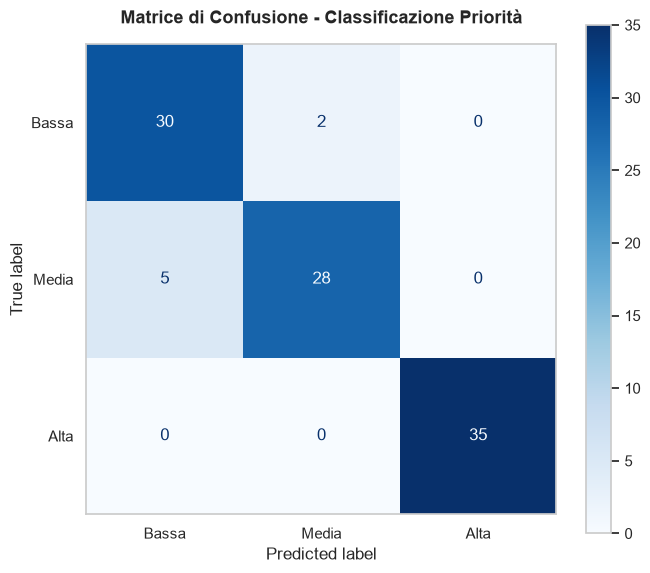

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Caricamento del dataset finale rimescolato
df = pd.read_csv("gemma_v3.csv")

# Uniamo titolo e corpo per dare al modello il massimo contesto possibile
df['testo_completo'] = df['title'] + " " + df['body']

X = df['testo_completo']
y = df['priority']

# 2. Divisione in Train Set (80%) e Test Set (20%)
# Usiamo stratify=y per essere sicuri che la proporzione di priorità sia identica nei due set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Vettorizzazione del testo tramite TF-IDF
# Rimuoviamo le stop_words italiane e consideriamo sia parole singole che coppie (ngram_range)
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), 
    max_features=3000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 4. Inizializzazione e Addestramento del Modello
# IMPORTANTE: class_weight='balanced' aiuta il modello a pesare di più la priorità "Alta"
# visto che numericamente ha meno record rispetto a Bassa e Media nel dataset totale.
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train_tfidf, y_train)

# 5. Predizione e Valutazione delle Performance
y_pred = model.predict(X_test_tfidf)

print("=== CLASSIFICATION REPORT (STIMA PRIORITÀ) ===")
print(classification_report(y_test, y_pred, target_names=['Alta', 'Bassa', 'Media']))

# 6. Generazione e Visualizzazione della Matrice di Confusione
labels_ordine = ['Bassa', 'Media', 'Alta'] # Ordine logico di gravità
cm = confusion_matrix(y_test, y_pred, labels=labels_ordine)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ordine)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Matrice di Confusione - Classificazione Priorità', fontsize=13, weight='bold', pad=15)
plt.grid(False) # Toglie le linee di griglia sopra la matrice
plt.tight_layout()
plt.show()

=== ESPERIMENTO 1: REGRESSIONE LOGISTICA ===
              precision    recall  f1-score   support

        Alta       1.00      1.00      1.00        35
       Bassa       0.86      0.94      0.90        32
       Media       0.93      0.85      0.89        33

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



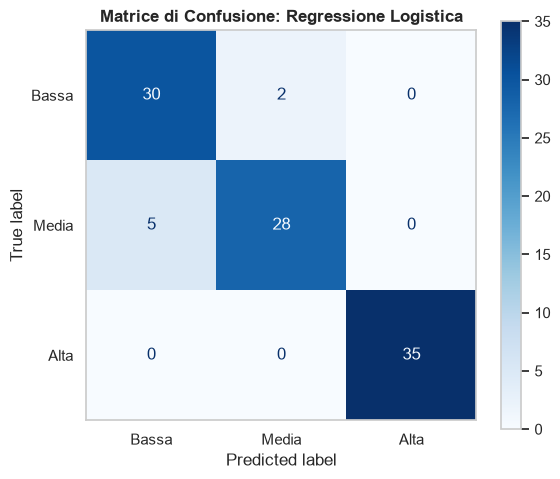


=== ESPERIMENTO 2: RANDOM FOREST CLASSIFIER ===
              precision    recall  f1-score   support

        Alta       0.95      1.00      0.97        35
       Bassa       0.77      0.84      0.81        32
       Media       0.86      0.73      0.79        33

    accuracy                           0.86       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.86      0.86      0.86       100



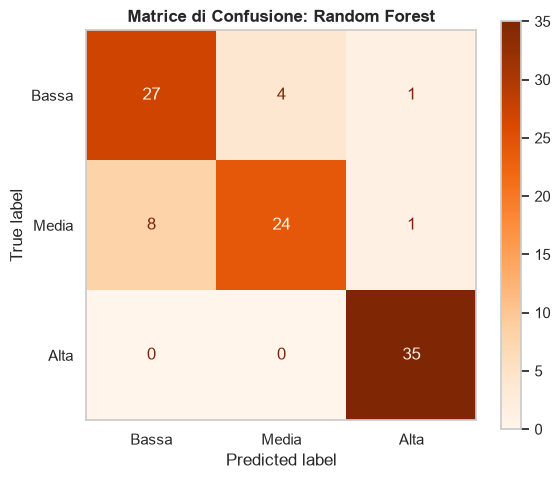

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Caricamento del dataset
df = pd.read_csv('gemma_v3.csv')

# Unione di titolo e corpo per massimizzare il contesto testuale
df['testo_completo'] = df['title'] + " " + df['body']

X = df['testo_completo']
y = df['priority']

# 2. Divisione in Train (80%) e Test (20%) con stratificazione
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Estrazione delle Feature tramite TF-IDF (unigrammi e bigrammi)
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Ordine logico delle priorità per la visualizzazione dei grafici
labels_ordine = ['Bassa', 'Media', 'Alta']

# =====================================================================
# ESPERIMENTO 1: REGRESSIONE LOGISTICA (Baseline Lineare)
# =====================================================================
print("=== ESPERIMENTO 1: REGRESSIONE LOGISTICA ===")
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_lr))

# Matrice di Confusione - Regressione Logistica
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels_ordine)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=labels_ordine)
fig, ax = plt.subplots(figsize=(6, 5))
disp_lr.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matrice di Confusione: Regressione Logistica', weight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()


# =====================================================================
# ESPERIMENTO 2: RANDOM FOREST (Modello Non Lineare a Insiemi di Alberi)
# =====================================================================
print("\n=== ESPERIMENTO 2: RANDOM FOREST CLASSIFIER ===")
# Usiamo class_weight='balanced' per gestire lo sbilanciamento nativo delle classi
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_rf))

# Matrice di Confusione - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels_ordine)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels_ordine)
fig, ax = plt.subplots(figsize=(6, 5))
disp_rf.plot(cmap='Oranges', ax=ax, values_format='d')
plt.title('Matrice di Confusione: Random Forest', weight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# =====================================================================
# 1. CARICAMENTO E PREPARAZIONE DATI
# =====================================================================
print("Caricamento del dataset in corso...")
df = pd.read_csv('gemma_v3.csv')

# Uniamo titolo e corpo per dare il massimo contesto a entrambi i modelli
df['testo_completo'] = df['title'] + " " + df['body']
X = df['testo_completo']

# =====================================================================
# 2. ADDESTRAMENTO MODELLO CATEGORIE (Amministrazione/Tecnico/Commerciale)
# =====================================================================
print("Addestramento del modello per le CATEGORIE...")
y_cat = df['category']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cat, test_size=0.20, random_state=42, stratify=y_cat
)

vectorizer_categoria = TfidfVectorizer(ngram_range=(1, 2), max_features=3000)
X_train_c_tfidf = vectorizer_categoria.fit_transform(X_train_c)

model_categoria = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model_categoria.fit(X_train_c_tfidf, y_train_c)

# =====================================================================
# 3. ADDESTRAMENTO MODELLO PRIORITÀ (Bassa/Media/Alta)
# =====================================================================
print("Addestramento del modello per le PRIORITÀ...")
y_prio = df['priority']
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_prio, test_size=0.20, random_state=42, stratify=y_prio
)

vectorizer_priorita = TfidfVectorizer(ngram_range=(1, 2), max_features=3000)
X_train_p_tfidf = vectorizer_priorita.fit_transform(X_train_p)

# Usiamo Random Forest per cercare di gestire la complessità della classe Media
model_priorita = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
model_priorita.fit(X_train_p_tfidf, y_train_p)

print("Tutti i modelli sono pronti!\n")

# =====================================================================
# 4. FUNZIONE DI PREDIZIONE SIMULTANEA
# =====================================================================
def analizza_nuovo_ticket_completo(testo_ticket):
    print("\n" + "="*60)
    print(f"RISULTATI ANALISI PER: '{testo_ticket}'")
    print("="*60)
    
    # --- Predizione Categoria ---
    testo_vet_cat = vectorizer_categoria.transform([testo_ticket])
    cat_stimata = model_categoria.predict(testo_vet_cat)[0]
    prob_cat = model_categoria.predict_proba(testo_vet_cat)[0]
    
    print(f"[CATEGORIA ASSEGNATA]: {cat_stimata.upper()}")
    print("Probabilità calcolate:")
    for c, p in zip(model_categoria.classes_, prob_cat):
        print(f"  - {c}: {p*100:.2f}%")
        
    print("-" * 40)
        
    # --- Predizione Priorità ---
    testo_vet_prio = vectorizer_priorita.transform([testo_ticket])
    prio_stimata = model_priorita.predict(testo_vet_prio)[0]
    prob_prio = model_priorita.predict_proba(testo_vet_prio)[0]
    
    print(f"[PRIORITÀ ASSEGNATA]: {prio_stimata.upper()}")
    print("Probabilità calcolate:")
    for c, p in zip(model_priorita.classes_, prob_prio):
        print(f"  - {c}: {p*100:.2f}%")
    print("="*60)

# =====================================================================
# 5. INTERFACCIA DI TEST DIRETTO
# =====================================================================
ticket_utente = input("Inserisci il testo di un ticket di esempio per testare il sistema: ")
analizza_nuovo_ticket_completo(ticket_utente)

Caricamento del dataset in corso...
Addestramento del modello per le CATEGORIE...
Addestramento del modello per le PRIORITÀ...
Tutti i modelli sono pronti!


RISULTATI ANALISI PER: ''
[CATEGORIA ASSEGNATA]: TECNICO
Probabilità calcolate:
  - Amministrazione: 28.23%
  - Commerciale: 33.34%
  - Tecnico: 38.43%
----------------------------------------
[PRIORITÀ ASSEGNATA]: MEDIA
Probabilità calcolate:
  - Alta: 4.00%
  - Bassa: 28.50%
  - Media: 67.50%


c'è da parlare della parte di analisi del sentimento


 VALUTAZIONE MODELLO: REGRESSIONE LOGISTICA
Accuracy Totale:  93.00%
F1-Score (Macro): 92.81%

Report di Classificazione Dettagliato:
              precision    recall  f1-score   support

        Alta       1.00      1.00      1.00        35
       Bassa       0.86      0.94      0.90        32
       Media       0.93      0.85      0.89        33

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100

[INFO] Matrice di confusione salvata come: valutazione_matrice_regressione_logistica.png


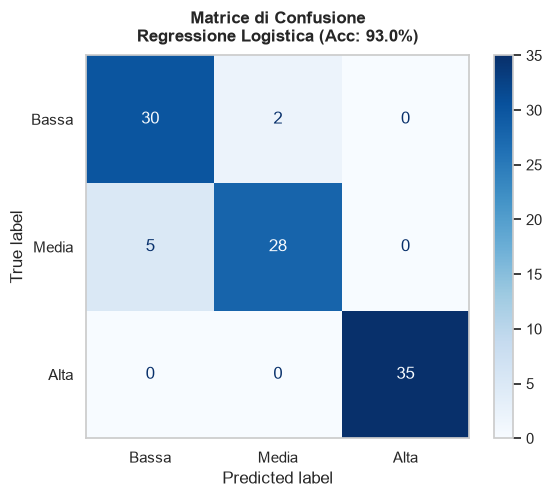


 VALUTAZIONE MODELLO: RANDOM FOREST
Accuracy Totale:  86.00%
F1-Score (Macro): 85.50%

Report di Classificazione Dettagliato:
              precision    recall  f1-score   support

        Alta       0.95      1.00      0.97        35
       Bassa       0.77      0.84      0.81        32
       Media       0.86      0.73      0.79        33

    accuracy                           0.86       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.86      0.86      0.86       100

[INFO] Matrice di confusione salvata come: valutazione_matrice_random_forest.png


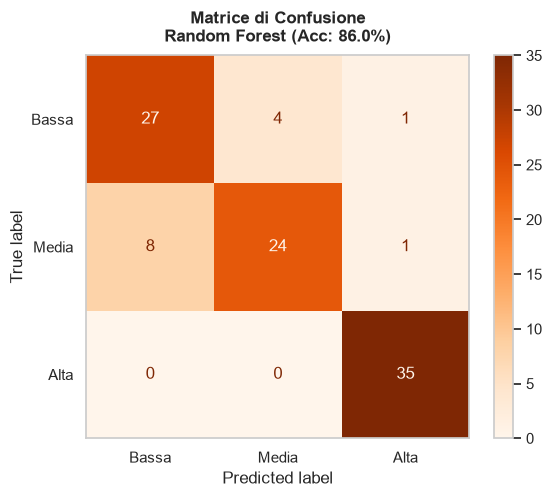

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =====================================================================
# 1. CARICAMENTO DATI
# =====================================================================
df = pd.read_csv('gemma_v3.csv')
df['testo_completo'] = df['title'] + " " + df['body']

X = df['testo_completo']
y = df['priority']  # Cambia in df['category'] se vuoi valutare le categorie

# Ordine logico delle classi per i grafici delle priorità
labels_ordine = ['Bassa', 'Media', 'Alta']

# =====================================================================
# 2. PARTIZIONAMENTO TRAIN/TEST (80/20)
# =====================================================================
# Lo stratify=y assicura che le proporzioni delle classi siano identiche nei due set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# =====================================================================
# 3. ESTRAZIONE DELLE FEATURE (TF-IDF)
# =====================================================================
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Inizializziamo i due modelli da confrontare
modelli = {
    "Regressione Logistica": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
}

# =====================================================================
# 4. ADDESTRAMENTO, VALUTAZIONE E MATRICE DI CONFUSIONE
# =====================================================================
for nome_modello, clf in modelli.items():
    print(f"\n" + "="*50)
    print(f" VALUTAZIONE MODELLO: {nome_modello.upper()}")
    print("="*50)
    
    # Addestramento
    clf.fit(X_train_tfidf, y_train)
    
    # Predizione
    y_pred = clf.predict(X_test_tfidf)
    
    # Calcolo delle metriche specifiche richieste
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    print(f"Accuracy Totale:  {acc*100:.2f}%")
    print(f"F1-Score (Macro): {f1_macro*100:.2f}%")
    print("\nReport di Classificazione Dettagliato:")
    print(classification_report(y_test, y_pred))
    
    # Calcolo della Matrice di Confusione
    cm = confusion_matrix(y_test, y_pred, labels=labels_ordine)
    
    # Visualizzazione Grafica della Matrice di Confusione
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ordine)
    
    # Scegliamo un colore diverso per distinguere i due esperimenti
    campa_colore = 'Blues' if nome_modello == "Regressione Logistica" else 'Oranges'
    disp.plot(cmap=campa_colore, ax=ax, values_format='d')
    
    plt.title(f'Matrice di Confusione\n{nome_modello} (Acc: {acc*100:.1f}%)', weight='bold', pad=10)
    plt.grid(False)
    plt.tight_layout()
    
    # Salvataggio automatico dell'immagine in alta definizione per la relazione
    nome_file_grafico = f"valutazione_matrice_{nome_modello.lower().replace(' ', '_')}.png"
    plt.savefig(nome_file_grafico, dpi=300)
    print(f"[INFO] Matrice di confusione salvata come: {nome_file_grafico}")
    plt.show()

Caricamento del dataset...
Estrazione delle feature sintattiche e di urgenza...
Vettorizzazione testo e combinazione delle feature...
Addestramento del Random Forest sulle feature combinate...

 RISULTATI DOPO FEATURE ENGINEERING (SOLUZIONE 1)
Accuracy Totale:  86.00%
F1-Score (Macro): 86.09%

Report di Classificazione Dettagliato:
              precision    recall  f1-score   support

        Alta       0.85      0.89      0.87        38
       Bassa       0.81      1.00      0.89        25
       Media       0.93      0.73      0.82        37

    accuracy                           0.86       100
   macro avg       0.86      0.87      0.86       100
weighted avg       0.87      0.86      0.86       100



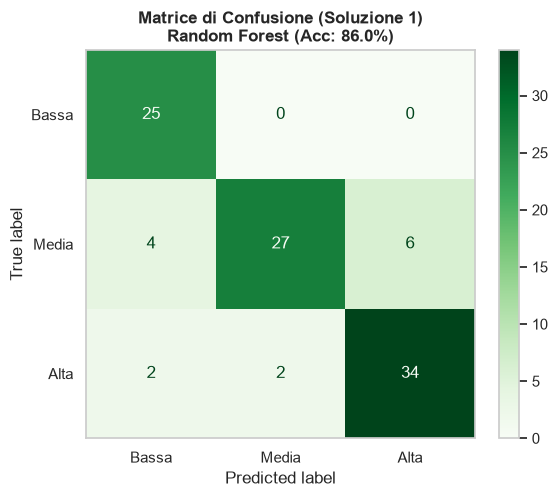

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.sparse import hstack, csr_matrix # Servono per unire i numeri al testo TF-IDF
import matplotlib.pyplot as plt

# =====================================================================
# 1. CARICAMENTO DATI
# =====================================================================
print("Caricamento del dataset...")
df = pd.read_csv('ticket_utenti_simulati_pro.csv')
df['testo_completo'] = df['title'] + " " + df['body']

# =====================================================================
# SOLUZIONE 1: CREAZIONE DELLE FEATURE SINTATTICHE (Urgente/Tono)
# =====================================================================
print("Estrazione delle feature sintattiche e di urgenza...")

# A. Conta i punti esclamativi (esprime panico o urgenza)
df['esclamativi'] = df['body'].apply(lambda x: str(x).count('!'))

# B. Conta le parole in tutto MAIUSCOLO (l'utente che "urla")
df['parole_maiuscole'] = df['body'].apply(lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 1))

# C. Cerca parole chiave di tempo o gravità tipiche dell'Alta priorità
parole_urgenti = ['subito', 'urgente', 'bloccato', 'domani', 'ora', 'immediato', 'crash', 'intervenite', 'inaccettabile', 'subitissimo']
df['ha_parole_urgenti'] = df['body'].apply(lambda x: sum(1 for p in parole_urgenti if p in str(x).lower()))

# D. Cerca parole tipiche della priorità Bassa (cortesia o nessuna fretta)
parole_calme = ['calma', 'tranquillamente', 'quando avete tempo', 'nessuna fretta', 'chiarimento', 'curiosità']
df['ha_parole_calme'] = df['body'].apply(lambda x: sum(1 for p in parole_calme if p in str(x).lower()))

# Matrice delle sole feature numeriche appena create
X_numeric = df[['esclamativi', 'parole_maiuscole', 'ha_parole_urgenti', 'ha_parole_calme']].values

# Feature testuale e Target
X_text = df['testo_completo']
y = df['priority']

# =====================================================================
# 2. PARTIZIONAMENTO TRAIN/TEST (80/20)
# =====================================================================
# Dividiamo contemporaneamente sia il testo sia la matrice numerica
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_numeric, y, test_size=0.20, random_state=42, stratify=y
)

# =====================================================================
# 3. VETTORIZZAZIONE TF-IDF E UNIONE DELLE FEATURE (HSTACK)
# =====================================================================
print("Vettorizzazione testo e combinazione delle feature...")
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=3000)

# Trasformiamo il testo in numeri (matrice sparsa TF-IDF)
X_train_tfidf = vectorizer.fit_transform(X_text_train)
X_test_tfidf = vectorizer.transform(X_text_test)

# Uniamo fisicamente la matrice TF-IDF con le nostre feature di urgenza/punti esclamativi
X_train_combinato = hstack([X_train_tfidf, csr_matrix(X_num_train)])
X_test_combinato = hstack([X_test_tfidf, csr_matrix(X_num_test)])

# =====================================================================
# 4. ADDESTRAMENTO RANDOM FOREST E VALUTAZIONE
# =====================================================================
print("Addestramento del Random Forest sulle feature combinate...")
rf_model = RandomForestClassifier(n_estimators=250, class_weight='balanced', random_state=42)
rf_model.fit(X_train_combinato, y_train)

# Predizione
y_pred = rf_model.predict(X_test_combinato)

# Calcolo metriche
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print("\n" + "="*50)
print(" RISULTATI DOPO FEATURE ENGINEERING (SOLUZIONE 1)")
print("="*50)
print(f"Accuracy Totale:  {acc*100:.2f}%")
print(f"F1-Score (Macro): {f1_macro*100:.2f}%")
print("\nReport di Classificazione Dettagliato:")
print(classification_report(y_test, y_pred))

# Matrice di Confusione Grafica
labels_ordine = ['Bassa', 'Media', 'Alta']
cm = confusion_matrix(y_test, y_pred, labels=labels_ordine)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ordine)
disp.plot(cmap='Greens', ax=ax, values_format='d') # Usiamo il verde per la soluzione 1
plt.title(f'Matrice di Confusione (Soluzione 1)\nRandom Forest (Acc: {acc*100:.1f}%)', weight='bold')
plt.grid(False)
plt.tight_layout()
plt.savefig('matrice_priorita_soluzione1.png', dpi=300)
plt.show()

Fase 1: Addestramento del modello di classificazione delle Categorie...
Fase 2: Addestramento dei modelli di priorità verticali per ogni reparto...
Fase 3: Esecuzione della pipeline sul Test Set...

 REPORT DI VALUTAZIONE DELLA PRIORITÀ (APPROCCIO GERARCHICO)
Accuracy Complessiva sulla Priorità: 91.00%

              precision    recall  f1-score   support

        Alta       0.97      1.00      0.98        29
       Bassa       0.81      0.90      0.85        29
       Media       0.95      0.86      0.90        42

    accuracy                           0.91       100
   macro avg       0.91      0.92      0.91       100
weighted avg       0.91      0.91      0.91       100



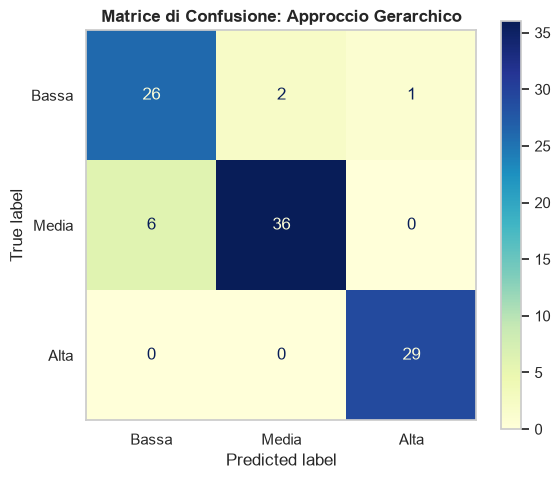

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =====================================================================
# 1. CARICAMENTO DATI
# =====================================================================
df = pd.read_csv('gemma_v3.csv')
df['testo_completo'] = df['title'].fillna('') + " " + df['body'].fillna('')

# Split principale (80% Train, 20% Test) mantenendo la proporzione delle categorie
train_df, test_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df['category']
)

# =====================================================================
# 2. STADIO 1: ADDESTRAMENTO MODELLO CATEGORIE
# =====================================================================
print("Fase 1: Addestramento del modello di classificazione delle Categorie...")
vectorizer_cat = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2))
X_train_cat = vectorizer_cat.fit_transform(train_df['testo_completo'])

model_cat = LinearSVC(random_state=42, dual=False)
model_cat.fit(X_train_cat, train_df['category'])

# Predizione della categoria sul Test Set (ci servirà per instradare i ticket)
X_test_cat = vectorizer_cat.transform(test_df['testo_completo'])
test_df['pred_category'] = model_cat.predict(X_test_cat)


# =====================================================================
# 3. STADIO 2: ADDESTRAMENTO MODELLI DI PRIORITÀ SPECIFICI PER CATEGORIA
# =====================================================================
print("Fase 2: Addestramento dei modelli di priorità verticali per ogni reparto...")
elenco_categorie = train_df['category'].unique()

# Dizionari per salvare i modelli e i vettorizzatori separati di ciascun reparto
modelli_priorita_reparto = {}
vectorizers_priorita_reparto = {}

for cat in elenco_categorie:
    # Filtriamo i dati del TRAIN SET tenendo solo quelli della categoria corrente
    train_sottogruppo = train_df[train_df['category'] == cat]
    
    # Creiamo un TF-IDF specifico per il vocabolario di questa categoria
    vec_prio = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2))
    X_train_prio_sub = vec_prio.fit_transform(train_sottogruppo['testo_completo'])
    
    # Addestriamo il classificatore di priorità specifico per questo reparto
    clf_prio_sub = LinearSVC(random_state=42, dual=False, class_weight='balanced')
    clf_prio_sub.fit(X_train_prio_sub, train_sottogruppo['priority'])
    
    # Salviamo le istanze
    modelli_priorita_reparto[cat] = clf_prio_sub
    vectorizers_priorita_reparto[cat] = vec_prio


# =====================================================================
# 4. SIMULAZIONE DELLA PIPELINE SUL TEST SET (Integrazione Gerarchica)
# =====================================================================
print("Fase 3: Esecuzione della pipeline sul Test Set...")
priorita_predette_finali = []

for idx, riga in test_df.iterrows():
    # Estradiamo la categoria stimata dallo Stadio 1
    categoria_stimata = riga['pred_category']
    testo_ticket = riga['testo_completo']
    
    # Selezioniamo il modello e il vettorizzatore dedicati a quel reparto
    vettorizzatore_specifico = vectorizers_priorita_reparto[categoria_stimata]
    modello_specifico = modelli_priorita_reparto[categoria_stimata]
    
    # Trasformiamo e prediciamo la priorità
    testo_vettorizzato = vettorizzatore_specifico.transform([testo_ticket])
    prio_stimata = modello_specifico.predict(testo_vettorizzato)[0]
    
    priorita_predette_finali.append(prio_stimata)

# Salviamo i risultati finali
test_df['pred_priority'] = priorita_predette_finali


# =====================================================================
# 5. VALUTAZIONE FINALE DEL SISTEMA GERARCHICO
# =====================================================================
print("\n" + "="*60)
print(" REPORT DI VALUTAZIONE DELLA PRIORITÀ (APPROCCIO GERARCHICO)")
print("="*60)
acc_prio = accuracy_score(test_df['priority'], test_df['pred_priority'])
print(f"Accuracy Complessiva sulla Priorità: {acc_prio*100:.2f}%\n")
print(classification_report(test_df['priority'], test_df['pred_priority']))

# Matrice di Confusione
labels_ordine = ['Bassa', 'Media', 'Alta']
cm = confusion_matrix(test_df['priority'], test_df['pred_priority'], labels=labels_ordine)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ordine)
disp.plot(cmap='YlGnBu', ax=ax, values_format='d')
plt.title('Matrice di Confusione: Approccio Gerarchico', weight='bold')
plt.grid(False)
plt.tight_layout()
plt.savefig('matrice_priorita_gerarchica.png', dpi=300)
plt.show()

Caricamento del dataset...
Addestramento del modello FastText con Gensim (estrazione n-grammi di caratteri)...
Trasformazione dei ticket in vettori numerici densi...
Addestramento del classificatore finale sui vettori FastText...

 RISULTATI VALUTAZIONE CON GENSIM FASTTEXT
Accuracy Totale:  83.00%
F1-Score (Macro): 82.64%

Report di Classificazione Dettagliato:
              precision    recall  f1-score   support

        Alta       0.97      0.97      0.97        35
       Bassa       0.79      0.72      0.75        32
       Media       0.72      0.79      0.75        33

    accuracy                           0.83       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.83      0.83      0.83       100



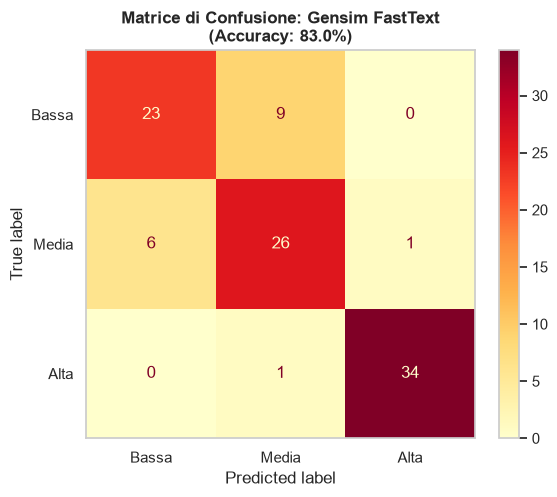

In [35]:
import pandas as pd
import numpy as np
from gensim.models import FastText
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =====================================================================
# 1. CARICAMENTO E PREPARAZIONE DATI
# =====================================================================
print("Caricamento del dataset...")
df = pd.read_csv('gemma_v3.csv')
df['testo_completo'] = df['title'].fillna('') + " " + df['body'].fillna('')

# Gensim ha bisogno del testo diviso in liste di parole (token) per l'addestramento
# Facciamo una tokenizzazione semplice dividendo per spazi e convertendo in minuscolo
df['tokenized'] = df['testo_completo'].apply(lambda x: str(x).lower().split())

X_tokens = df['tokenized'].tolist()
y = df['priority']

# =====================================================================
# 2. SUDDIVISIONE IN TRAIN E TEST SET (80/20)
# =====================================================================
X_train_tokens, X_test_tokens, y_train, y_test = train_test_split(
    X_tokens, y, test_size=0.20, random_state=42, stratify=y
)

# =====================================================================
# 3. ADDESTRAMENTO DEL MODELLO FASTTEXT (GENSIM)
# =====================================================================
print("Addestramento del modello FastText con Gensim (estrazione n-grammi di caratteri)...")
# vector_size=100: dimensione del vettore semantico
# window=5: contesto di parole vicine
# min_count=1: considera anche parole rare (visto che il dataset è piccolo)
# min_n=3, max_n=6: la magia di FastText, scompone le parole in sotto-parti da 3 a 6 caratteri
model_ft = FastText(sentences=X_train_tokens, vector_size=100, window=5, min_count=1, min_n=3, max_n=6, epochs=30, workers=4)

# =====================================================================
# 4. FUNZIONE PER TRASFORMARE I TICKET IN VETTORI MEDI
# =====================================================================
# Questa funzione prende la lista di parole di un ticket e restituisce un unico vettore medio da 100 dimensioni
def genera_vettore_medio_ticket(tokens, modello):
    vettori_parole = []
    for token in tokens:
        # Se la parola è nuova, FastText userà le sottoparole (subwords) per calcolare comunque il vettore!
        vettori_parole.append(modello.wv[token])
    
    if len(vettori_parole) > 0:
        return np.mean(vettori_parole, axis=0)
    else:
        return np.zeros(modello.vector_size) # Vettore di zeri se il testo fosse vuoto

print("Trasformazione dei ticket in vettori numerici densi...")
X_train_vectors = np.array([genera_vettore_medio_ticket(t, model_ft) for t in X_train_tokens])
X_test_vectors = np.array([genera_vettore_medio_ticket(t, model_ft) for t in X_test_tokens])

# =====================================================================
# 5. ADDESTRAMENTO DEL CLASSIFICATORE FINALE (REGRESSIONE LOGISTICA)
# =====================================================================
print("Addestramento del classificatore finale sui vettori FastText...")
# Usiamo la Regressione Logistica bilanciata per gestire le classi
classificatore = LogisticRegression(class_weight='balanced', random_state=42, max_iter=2000)
classificatore.fit(X_train_vectors, y_train)

# Predizione
y_pred = classificatore.predict(X_test_vectors)

# =====================================================================
# 6. VALUTAZIONE E METRICHE
# =====================================================================
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print("\n" + "="*50)
print(" RISULTATI VALUTAZIONE CON GENSIM FASTTEXT")
print("="*50)
print(f"Accuracy Totale:  {acc*100:.2f}%")
print(f"F1-Score (Macro): {f1_macro*100:.2f}%")
print("\nReport di Classificazione Dettagliato:")
print(classification_report(y_test, y_pred))

# Grafico della Matrice di Confusione
labels_ordine = ['Bassa', 'Media', 'Alta']
cm = confusion_matrix(y_test, y_pred, labels=labels_ordine)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ordine)
disp.plot(cmap='YlOrRd', ax=ax, values_format='d')
plt.title(f'Matrice di Confusione: Gensim FastText\n(Accuracy: {acc*100:.1f}%)', weight='bold')
plt.grid(False)
plt.tight_layout()
plt.savefig('matrice_priorita_gensim_fasttext.png', dpi=300)
plt.show()

- TF-IDF + Modelli Lineari (Baseline): 54% => Primo tentativo ma miglior risultato. 
- Approccio Gerarchico a due stadi: 42% => Provato a dividere il dataset in dei sotto-dataset in base alle categorie. Lo scopo era quello di allenare il modello a riconoscere la priorità in base alla categoria di appartenenza. Soluzione che ho trovato molto interessante da implementare, ma la poca quantità di dati nel dataset non ha aiutato a rendere il risultato finale soddisfacente.
- FastText da zero: 33% => Evidenzia come il dataset troppo piccolo sia un problema se applicato a modelli vettoriali complessi.

- provare a mischiare i dataset
- vedere cose di bert
- clip


In [36]:
import re
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- LA TUA FUNZIONE DI PULIZIA ---
def clean_text(text):
    text = str(text).lower()
    # Rimuove tutto ciò che NON è alfanumerico o spazio
    text = re.sub(r'[^\w\s]', '', text)
    # Rimuove spazi multipli e fa lo strip
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# =====================================================================
# 1. CARICAMENTO E UNIONE DEI DATASET (DATA MIXING 50/50)
# =====================================================================
print("Caricamento dei dataset...")
df_gemma = pd.read_csv('gemmav2.csv')
df_pseudo = pd.read_csv('gemma_v3.csv') 

# Estraiamo il 50% dei dati da ciascun dataset
frac_gemma = df_gemma.sample(frac=0.5, random_state=42)
frac_pseudo = df_pseudo.sample(frac=0.5, random_state=42)

# Uniamo e mescoliamo
df_misto = pd.concat([frac_gemma, frac_pseudo], ignore_index=True)
df_misto = df_misto.sample(frac=1, random_state=42).reset_index(drop=True)

# Uniamo titolo e corpo del testo
df_misto['testo_completo'] = df_misto['title'].fillna('') + " " + df_misto['body'].fillna('')

# --- APPLICAZIONE DELLA TUA PULIZIA ---
print("Pulizia e normalizzazione del testo in corso...")
df_misto['testo_completo'] = df_misto['testo_completo'].apply(clean_text)

# =====================================================================
# 2. SUDDIVISIONE IN TRAIN E TEST SET (80/20)
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    df_misto['testo_completo'], 
    df_misto['priority'], 
    test_size=0.20, 
    random_state=42, 
    stratify=df_misto['priority']
)

# =====================================================================
# 3. VETTORIZZAZIONE (TF-IDF) E MODELLO (LINEARSVC)
# =====================================================================
print("Estrazione delle feature tramite TF-IDF...")
vectorizer = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Addestramento del classificatore LinearSVC...")
model = LinearSVC(random_state=42, dual=False, class_weight='balanced')
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

# =====================================================================
# 4. VALUTAZIONE
# =====================================================================
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print("\n" + "="*50)
print(" RISULTATI CON DATASET IBRIDO + TESTO PULITO")
print("="*50)
print(f"Accuracy Totale:  {acc*100:.2f}%")
print(f"F1-Score (Macro): {f1_macro*100:.2f}%")
print("\nReport di Classificazione Dettagliato:")
print(classification_report(y_test, y_pred))

Caricamento dei dataset...
Pulizia e normalizzazione del testo in corso...
Estrazione delle feature tramite TF-IDF...
Addestramento del classificatore LinearSVC...

 RISULTATI CON DATASET IBRIDO + TESTO PULITO
Accuracy Totale:  67.00%
F1-Score (Macro): 65.79%

Report di Classificazione Dettagliato:
              precision    recall  f1-score   support

        Alta       0.74      0.91      0.82        34
       Bassa       0.62      0.59      0.61        34
       Media       0.62      0.50      0.55        32

    accuracy                           0.67       100
   macro avg       0.66      0.67      0.66       100
weighted avg       0.66      0.67      0.66       100



Caricamento del dataset (Solo Gemma)...
Pulizia e normalizzazione del testo in corso...
Estrazione delle feature tramite TF-IDF...
Addestramento del classificatore LinearSVC...

 RISULTATI CON SOLO DATASET GEMMA + TESTO PULITO
Accuracy Totale:  93.00%
F1-Score (Macro): 92.82%

Report di Classificazione Dettagliato:
              precision    recall  f1-score   support

        Alta       1.00      1.00      1.00        35
       Bassa       0.88      0.91      0.89        32
       Media       0.91      0.88      0.89        33

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



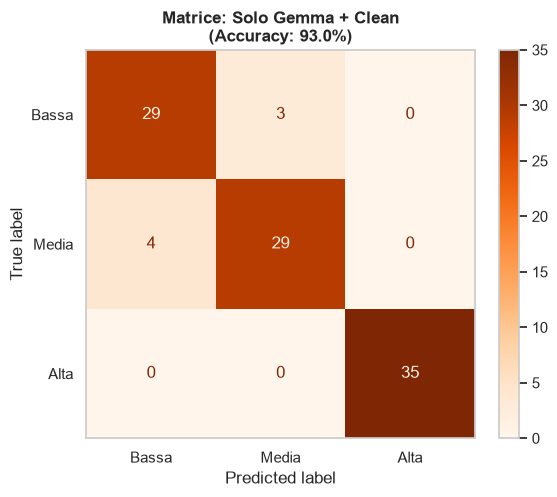

In [37]:
import re
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- LA TUA FUNZIONE DI PULIZIA ---
def clean_text(text):
    text = str(text).lower()
    # Rimuove tutto ciò che NON è un carattere alfanumerico o spazio
    text = re.sub(r'[^\w\s]', '', text)
    # Normalizza gli spazi multipli
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# =====================================================================
# 1. CARICAMENTO DATI (SOLO DATASET GEMMA)
# =====================================================================
print("Caricamento del dataset (Solo Gemma)...")
df_gemma = pd.read_csv('gemma_v3.csv')

# Uniamo titolo e corpo del testo originale di Gemma
df_gemma['testo_completo'] = df_gemma['title'].fillna('') + " " + df_gemma['body'].fillna('')

# --- APPLICAZIONE DELLA TUA PULIZIA ---
print("Pulizia e normalizzazione del testo in corso...")
df_gemma['testo_completo'] = df_gemma['testo_completo'].apply(clean_text)

# =====================================================================
# 2. SUDDIVISIONE IN TRAIN E TEST SET (80/20)
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    df_gemma['testo_completo'], 
    df_gemma['priority'], 
    test_size=0.20, 
    random_state=42, 
    stratify=df_gemma['priority']
)

# =====================================================================
# 3. VETTORIZZAZIONE (TF-IDF) E MODELLO (LINEARSVC)
# =====================================================================
print("Estrazione delle feature tramite TF-IDF...")
vectorizer = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Addestramento del classificatore LinearSVC...")
# Manteniamo class_weight='balanced' per confrontarlo equamente con il test misto
model = LinearSVC(random_state=42, dual=False, class_weight='balanced')
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

# =====================================================================
# 4. VALUTAZIONE
# =====================================================================
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print("\n" + "="*50)
print(" RISULTATI CON SOLO DATASET GEMMA + TESTO PULITO")
print("="*50)
print(f"Accuracy Totale:  {acc*100:.2f}%")
print(f"F1-Score (Macro): {f1_macro*100:.2f}%")
print("\nReport di Classificazione Dettagliato:")
print(classification_report(y_test, y_pred))

# Matrice di Confusione
labels_ordine = ['Bassa', 'Media', 'Alta']
cm = confusion_matrix(y_test, y_pred, labels=labels_ordine)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ordine)
disp.plot(cmap='Oranges', ax=ax, values_format='d')
plt.title(f'Matrice: Solo Gemma + Clean\n(Accuracy: {acc*100:.1f}%)', weight='bold')
plt.grid(False)
plt.tight_layout()
plt.savefig('matrice_priorita_solo_gemma_pulito.png', dpi=300)
plt.show()